# Instructor Effectiveness Modeling (Edtech Context)
## Objective

The goal of this project to analyze instructor performance using learner outcome, engagement and feedback matrics.

This notebook includes:
- Exploratory Data Analysis (EDA)
- Instructor Effectiveness score definition
- Feature aggregation
- Machine learning model
- Model Evaluation
- Business Insights and Limitations.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.listdir()

['.config', 'sample_data']

In [3]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


In [4]:
from google.colab import files

uploaded = files.upload()

Saving instructor_effectiveness_dataset_2000_rows.xlsx to instructor_effectiveness_dataset_2000_rows.xlsx


In [5]:
import os
print(os.listdir('/content'))

['.config', 'instructor_effectiveness_dataset_2000_rows.xlsx', 'sample_data']


In [6]:
df = pd.read_excel("/content/instructor_effectiveness_dataset_2000_rows.xlsx")

In [7]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [8]:
df.shape

(2000, 12)

In [9]:
df.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


## Initial observation

- The data contains 2000 rows and 12 columns.
- No missing Value are present.
- three columns (batch_id, instructor_id, course_id) are identifier.
- Nine columns contain numerical data for analysis.
- The data set is clean and ready to Exploratory Data Analysis (EDA).

In [11]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


## Exploratory Data Analysis (EDA)

The purpose of Exploratory Data Analysis (EDA) is to understand the dataset, identify the patterns and explore relation between variable before building the machine learning.

In [12]:
df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


## Observation
No missing value were found in the dataset. Therefore no missing value required before Analysis.

In [13]:
df.duplicated().sum()

np.int64(0)

### Observation

The dataset does not contain duplicate rows. Therefore, no duplicate removal is required.

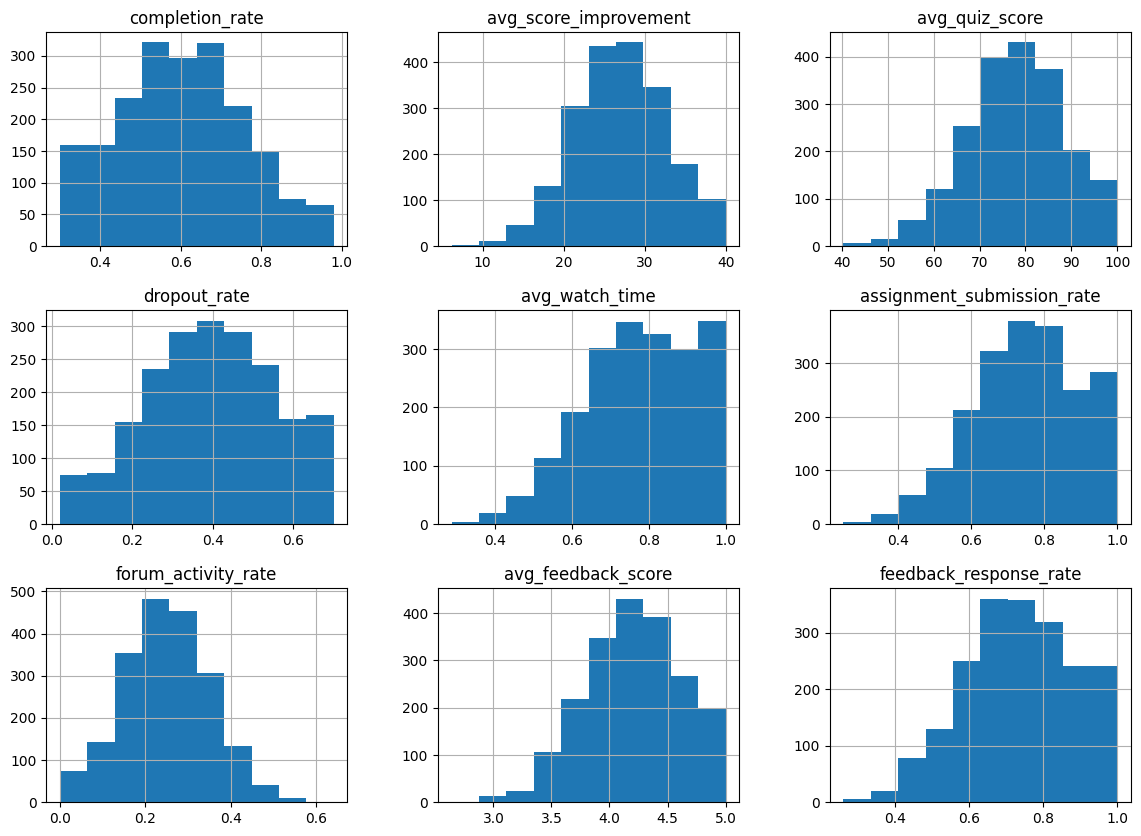

In [14]:
df.hist(figsize=(14,10))
plt.show()

### Observations

- Most numerical features show a fairly normal distribution.
- Average quiz scores are mostly between 70 and 90.
- Average feedback scores are generally high (around 4 to 4.5).
- Forum activity is lower compared to other engagement metrics.
- No obvious extreme outliers are visible from the histograms.

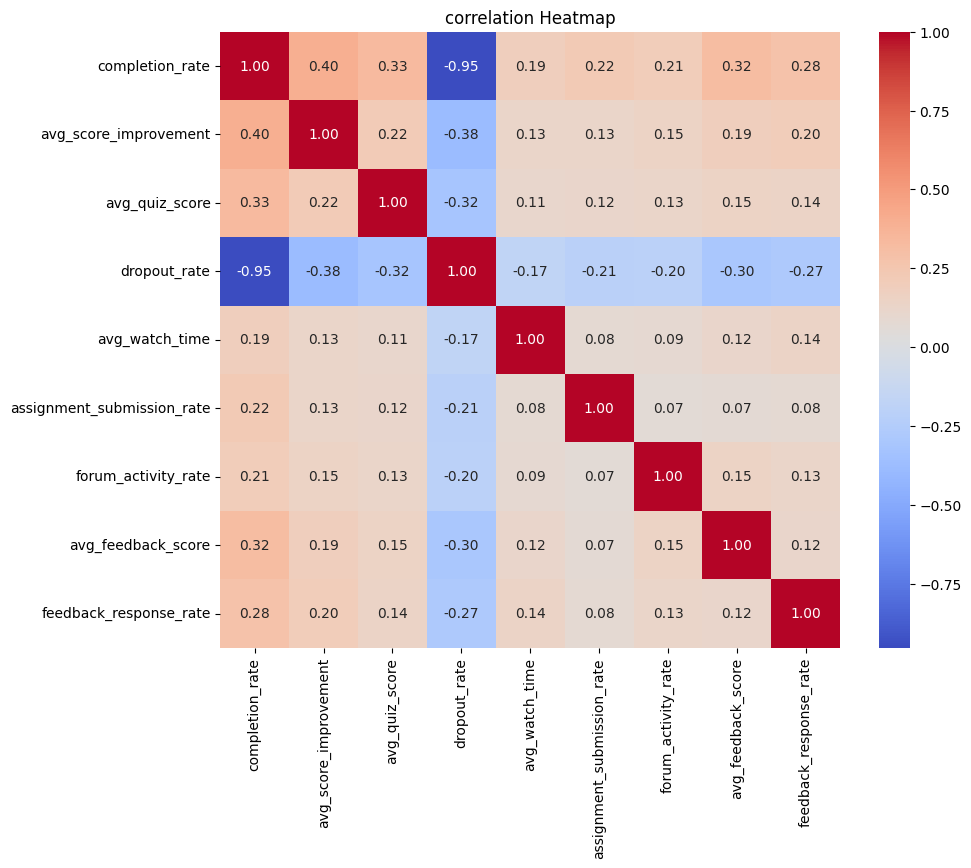

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(df.select_dtypes(include= 'number').corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.title("correlation Heatmap")
plt.show()

## Step 3: Aggregate Batch Data to Instructor Level

Since one instructor may teach multiple batches, the data is aggregated at the instructor level.

We use the **mean** of each performance metric because it represents the instructor's overall performance across all batches.

This creates one record per instructor, which is suitable for evaluating instructor effectiveness.

In [16]:
# Aggregate batch-level data to instructor level

instructor_df = df.groupby("instructor_id").agg({
    "completion_rate": "mean",
    "avg_score_improvement":"mean",
    "avg_quiz_score":"mean",
    "dropout_rate":"mean",
    "avg_watch_time":"mean",
    "assignment_submission_rate":"mean",
    "forum_activity_rate":"mean",
    "avg_feedback_score":"mean",
    "feedback_response_rate":"mean"
}).reset_index()

In [17]:
instructor_df.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197


In [18]:
instructor_df.shape

(120, 10)

## Calculating Instructor Effectiveness Score

The effectiveness score is calculated using learner outcomes, engagement, and feedback metrics.

Before combining the metrics, features with different scales are normalized so that all metrics contribute fairly.

Higher completion, quiz score, score improvement, engagement, and feedback indicate better performance, while lower dropout rate indicates better performance.

Weights are assigned based on their assumed importance in evaluating instructor effectiveness.

In [19]:
# Normalize feature
max_improvement = instructor_df["avg_score_improvement"].max()

instructor_df["effectiveness_score"]= (
    0.25*instructor_df["completion_rate"] +
    0.20*(1 - instructor_df["dropout_rate"]) +
    0.15*(instructor_df["avg_quiz_score"]/100) +
    0.10*(instructor_df["avg_score_improvement"] / max_improvement) +
    0.10*(instructor_df["avg_feedback_score"] / 5) +
    0.05*instructor_df["avg_watch_time"] +
    0.05*instructor_df["assignment_submission_rate"] +
    0.05*instructor_df["forum_activity_rate"] +
    0.05*instructor_df["feedback_response_rate"]
)

In [20]:
instructor_df.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,0.642430
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,0.763576
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,0.777856
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,0.593869
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,0.834160


In [21]:
instructor_df[["instructor_id", "effectiveness_score"]].head()

,instructor_id,effectiveness_score
0,I_001,0.642430
1,I_002,0.763576
2,I_003,0.777856
3,I_004,0.593869
4,I_005,0.834160


## Creating Instructor effectiveness tiers

The continuous effectiveness score is converted into three categories:

-Low

-Medium

-High

The dataset is divided into three equal groups using quantiles.

In [22]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [23]:
instructor_df[["instructor_id", "effectiveness_score", "effectiveness_tier"]].head(10)

,instructor_id,effectiveness_score,effectiveness_tier
0,I_001,0.642430,Low
1,I_002,0.763576,High
2,I_003,0.777856,High
3,I_004,0.593869,Low
4,I_005,0.834160,High
5,I_006,0.551479,Low
6,I_007,0.744697,High
7,I_008,0.706559,High
8,I_009,0.691867,Medium
9,I_010,0.897205,High


In [24]:
instructor_df["effectiveness_tier"].value_counts()

,count
effectiveness_tier,
Low,40
Medium,40
High,40


## Step 4: Build a Machine Learning Model

A Decision Tree Classifier is used to predict instructor effectiveness tiers (Low, Medium, High).

The dataset is divided into training and testing sets.

The model learns patterns from the training data and predicts effectiveness tiers on the test data.


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
X = instructor_df.drop(columns=['instructor_id', 'effectiveness_score', 'effectiveness_tier'])

Y = instructor_df['effectiveness_tier']

In [27]:
X.head()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858
1,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338
2,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132
3,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460
4,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197


In [28]:
Y.head()

,effectiveness_tier
0,Low
1,High
2,High
3,Low
4,High


In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [30]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(96, 9)
(24, 9)
(96,)
(24,)


## Training the decision tree model

A decision tree classification is trained using the training dataset.

The Model learns the relationship between instructor performance matrics and effectiveness tiers.

In [31]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

In [32]:
Y_pred = model.predict(X_test)

In [33]:
print(Y_pred)

['Low' 'High' 'High' 'High' 'Low' 'Medium' 'Low' 'Medium' 'Medium'
 'Medium' 'Low' 'Medium' 'Medium' 'High' 'High' 'Medium' 'Medium' 'Low'
 'Low' 'High' 'High' 'Medium' 'Low' 'High']


In [34]:
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.875


## Model Evaluation

The model is evaluated using Accuracy, Precision, Recall and F1-score.

These metrics help assess how well the model predicts instructor effectiveness tiers.

In [35]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

        High       0.75      1.00      0.86         6
         Low       0.86      1.00      0.92         6
      Medium       1.00      0.75      0.86        12

    accuracy                           0.88        24
   macro avg       0.87      0.92      0.88        24
weighted avg       0.90      0.88      0.87        24



The confusion metrix shows that most instructor effectiveness tiers were classified correctly. A few Medium/High instructors were misclassified, indicating some overlap between these effectiveness levels. Overall, the model performs well with limited classification errors.

In [36]:
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[6 0 0]
 [0 6 0]
 [2 1 9]]


## Feature Importance

Feature Importance show which variable contributed the most to predicting instructor effectiveness.

This helps understand which instructor related matrics are most influential in the model.

In [37]:
feature_importance = pd.DataFrame({
    "Feature": X.columns ,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,completion_rate,0.494205
3,dropout_rate,0.360618
5,assignment_submission_rate,0.050624
1,avg_score_improvement,0.028783
6,forum_activity_rate,0.020915
4,avg_watch_time,0.015686
2,avg_quiz_score,0.014790
8,feedback_response_rate,0.014379
7,avg_feedback_score,0.000000


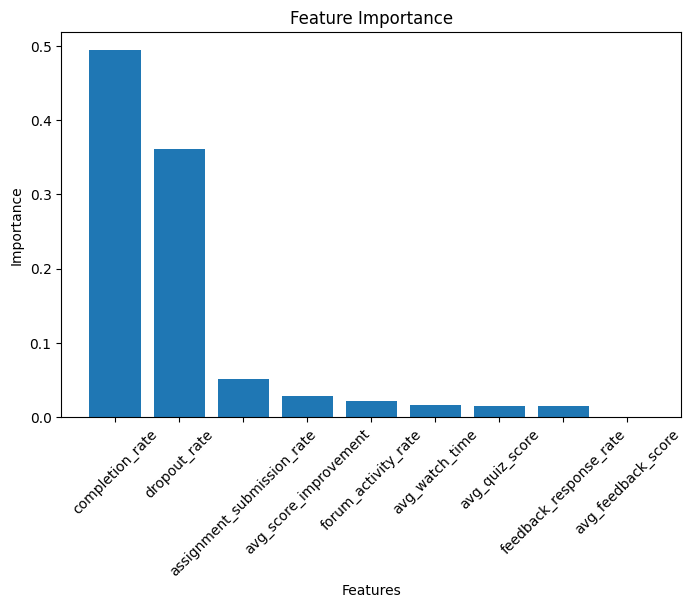

In [38]:
plt.figure(figsize=(8,5))

plt.bar(feature_importance["Feature"],
        feature_importance["Importance"])

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

## Mandatory Analysis Questions

### 1. Which features most influenced instructor effectiveness, and why?

Based on the feature importance analysis, completion rate and dropout rate were the most influential features.

A higher completion rate means more learners successfully completed the course, while a lower dropout rate indicates better learner engagement.

These two metrics directly reflect overall instructor effectiveness.

### 2. Which variables could be misleading or confounded?

Some variables may be affected by factor other than instructor performance.

For example, quiz score may depend on course difficulty, and feedback score may be influenced by student expectations.

Similarly, forum activity can vary depending on the type of course.

### 3. How could this model fail in real-world usage?

This model may not perform equally well for new instructors or different types of courses.

It also does not consider external factors such as course difficulty, student background, or class size.

Therefore, the predictions should be interpreted carefully.

### 4. What additional data would you want to improve this analysis?

The analysis could be improved by adding more information such as:

- Instructor teaching experience
- Course difficulty level
- Batch size
- Student attendance
- Student comments and reviews
- Live session participation

## 5. Should this model be used for instructor performance evaluation? Why or why not?

This model should be used as a supporting tool instead of the only method for evaluating instructors.

It provide useful insights, but final decisions should also include human judgment and other qualitative information.

# Conclusion

In this project, Instructor effectiveness was estimated using learner outcomes, engagement, and feedback metrics.
Batch-level data was aggregated to the instructor level, and an effectiveness score was created to classify instructors into low, medium and high effectiveness tiers.
A Decision Tree Classifier achieved an accuracy of approximately 87.5%.
The results showed that completion rate and dropout rate were the most important factors influencing instructor effectiveness.
This model can support instructor evaluation, but it should be used along with human judgment and additional information.